## Clustering

## Introduccion

El término clustering hace referencia a un amplio abanico de técnicas no supervisadas cuya finalidad es encontrar patrones o grupos ( clusters ) dentro de un conjunto de observaciones. Las particiones se establecen de forma que, las observaciones que están dentro de un mismo grupo, son similares entre ellas y distintas a las observaciones de otros grupos. Se trata de un método no supervisado , ya que el proceso ignora la variable respuesta que indica a qué grupo pertenece realmente cada observación (si es que existe tal variable). Esta característica diferencia al clustering de las técnicas supervisadas , que emplean un conjunto de entrenamiento en el que se conoce la verdadera clasificación.

Dada la utilidad del clustering en disciplinas muy distintas (genómica, marketing…), se han desarrollado multitud de variantes y adaptaciones de sus métodos y algoritmos. Pueden diferenciarse tres grupos principales:

- Particionado Agrupamiento : Este tipo de algoritmos requieren que el usuario especifique de antemano el número de clusters que se van a crear ( K-means , K-medoids , CLARA ).

- Agrupamiento jerárquico : este tipo de algoritmos no requiere que el usuario especifique de antemano el número de clústeres . ( agrupamiento aglomerativo , agrupamiento divisivo ).

- Métodos que combinan o modifican los anteriores ( K-medias jerárquicas , agrupamiento difuso , agrupamiento basado en modelos y agrupamiento basado en densidad ).

## Descripcion Funciones

- stats: contiene las funciones dist()para calcular matrices de distancias, kmeans(), hclust(), cuttree()para crear los clusters y plot.hclust()para visualizar los resultados.

- cluster, mclust: contienen múltiples algoritmos de clustering y métricas para evaluarlos.

- factoextra:extensión basada en ggplot2para crear visualizaciones de los resultados de clustering y su evaluación.

- dendextend: extensión para la personalización de dendrogramas.

La base correposnde al comportamiento del area sembrada y cosechas para un periodo de una año, el producto corresponde a hortalizas.

https://cienciadedatos.net/documentos/37_clustering_y_heatmaps

In [ ]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import importlib

from sklearn.datasets import make_blobs, make_moons
from sklearn.cluster import KMeans, SpectralClustering, AgglomerativeClustering, DBSCAN
from IPython.display import HTML
from sklearn.metrics import silhouette_score
%matplotlib inline

In [ ]:
import pandas as pd
Y = pd.read_excel('/content/Evaluaciones_Agropecuarias.xlsx').values+20

In [ ]:
Y

array([[ 22,  21],
       [102, 100],
       [ 22,  22],
       ...,
       [ 35,  35],
       [ 26,  26],
       [ 25,  25]])

Text(0, 0.5, 'AREA DE COSECHA')

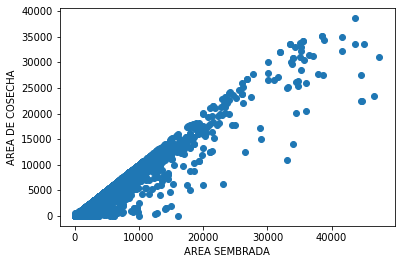

In [ ]:
plt.scatter(Y[:,0], Y[:,1])
plt.xlabel("AREA SEMBRADA")
plt.ylabel("AREA DE COSECHA")

In [ ]:
X = pd.read_excel('/content/Evaluaciones_Agropecuarias.xlsx').values+20
n_clusters = 2

km = KMeans( n_clusters = n_clusters)
km.fit(X)
y = km.predict(X)
y

array([0, 0, 0, ..., 0, 0, 0], dtype=int32)

## Usamos `pandas` para contar el número de elementos en cada cluster:

In [ ]:
pd.Series(y).value_counts()

0    203815
1      2253
dtype: int64

## Las coordenadas de los centroides se pueden obtener con `cluster_centers`:

In [ ]:
km.cluster_centers_

array([[ 220.80003925,  192.49982582],
       [8477.58588549, 7227.86950732]])

## El siguiente código dibuja los datos agrupados junto con los centroides:

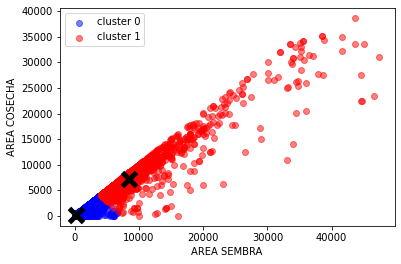

In [ ]:

cmap = plt.cm.plasma

cmap((y*255./(n_clusters-1)).astype(int))
for i in np.unique(y):
    cmap = plt.cm.bwr
    col = cmap((i*255./(n_clusters-1)).astype(int))
    Xr = X[y==i]
    plt.scatter(Xr[:,0], Xr[:,1], color=col, label="cluster %d"%i, alpha=.5)
plt.scatter(km.cluster_centers_[:,0], km.cluster_centers_[:,1],marker="x", lw=5, s=200, color="black")
plt.legend()
plt.xlabel("AREA SEMBRA")
plt.ylabel("AREA COSECHA");

##METODO DE CODO

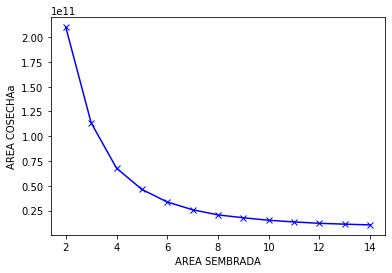

In [ ]:
X = pd.read_excel('/content/Evaluaciones_Agropecuarias.xlsx').values+20
Sum_of_squared_distances = []
K = range(2,15)
for k in K:
    km = KMeans(n_clusters=k)
    km = km.fit(X)
    Sum_of_squared_distances.append(km.inertia_)

plt.plot(K, Sum_of_squared_distances, 'bx-')
plt.xlabel('AREA SEMBRADA')
plt.ylabel('AREA COSECHAa')
plt.show()

### Coeficiente de silueta

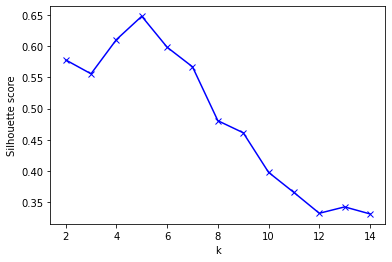

array([ 1,  3,  1, 11,  1, 10, 12, 12,  6,  8,  4,  2, 12,  7,  8,  7,  4,
       10,  9,  8,  9,  9, 13,  1,  9,  4,  6,  0,  9,  6,  3,  2,  5,  8,
       12,  3,  4,  2,  8,  6,  6,  2,  3,  9, 10,  0, 10,  7, 11, 10,  0,
        8, 12,  9,  4,  1,  0, 12, 13,  9,  1,  6,  0,  3,  0,  5,  1,  1,
       11,  2,  6, 10, 10, 11,  2, 11,  2,  5,  0,  8,  6,  0,  5,  1, 12,
        0,  7, 11, 11,  5,  3,  7,  6,  0,  5,  9,  0,  7,  3,  5,  1,  2,
        0,  6, 10, 12, 12,  5,  6, 11, 13,  5,  4,  1, 10,  1,  8,  0, 12,
        6,  3, 13, 10,  7, 11, 13, 10,  9,  4,  9,  1, 10,  5, 13, 12,  8,
        6, 10, 10,  6,  6, 10,  8,  2,  8,  3,  3,  8,  1,  0,  0, 13, 13,
       10, 10,  4, 13,  9,  9,  3, 10,  1, 10,  9,  6,  6,  6,  8,  5,  6,
        4, 11, 10,  3,  3,  2,  0,  2, 10, 10, 10, 10,  2,  5,  1,  7, 10,
       11,  1,  5, 13,  8, 11,  1,  0,  9,  1,  8,  9,  9,  9,  9,  4,  1,
        8,  8,  3, 12,  6,  0, 10, 10,  4,  5, 12, 10,  1, 11,  1, 12, 10,
        8,  3, 11,  3,  1

In [ ]:
X,_ = make_blobs(500, cluster_std=1.5, centers=6, random_state=10)
silhouette_scores = []
K = range(2,15)
for k in K:
    km = KMeans(n_clusters=k)
    km = km.fit(X)
    y = km.predict(X)
    silhouette_scores.append(silhouette_score(X, y))

plt.plot(K, silhouette_scores, 'bx-')
plt.xlabel('k')
plt.ylabel('Silhouette score')
plt.show()
y